In [11]:
import sympy as sp
from control import tf, step_response, poles, zeros, pzmap
import matplotlib.pyplot as plt
import numpy as np

# Create symbolic variables for Laplace domain
s = sp.symbols('s')
X = sp.symbols('X')
Y = sp.symbols('Y')

In [12]:
# Represent the given equation in Laplace form
# Left side: output terms
A = 2*s**2 * Y + s * Y
# Right side: input terms
B = s * X + X

In [13]:
# Solve the equation to express Y in terms of X, then get G(s) = Y/X
tf_expr = sp.solve(sp.Eq(A, B), Y)[0] / X
# Simplify the transfer function expression
tf_simplified = sp.simplify(tf_expr)

print(f"Calculated Transfer Function G(s): {tf_simplified}")

Calculated Transfer Function G(s): (s + 1)/(s*(2*s + 1))


In [14]:
# Extract numerator and denominator coefficients for control system use
num_coeffs = [float(c) for c in sp.Poly(sp.numer(tf_simplified), s).all_coeffs()]
den_coeffs = [float(c) for c in sp.Poly(sp.denom(tf_simplified), s).all_coeffs()]

# Build the transfer function model
sys = tf(num_coeffs, den_coeffs)
print(sys)

<TransferFunction>: sys[4]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    s + 1
  ---------
  2 s^2 + s


In [15]:
# Display system poles and zeros
print(f"Poles: {poles(sys)}")
print(f"Zeros: {zeros(sys)}")

Poles: [-0.5+0.j  0. +0.j]
Zeros: [-1.+0.j]


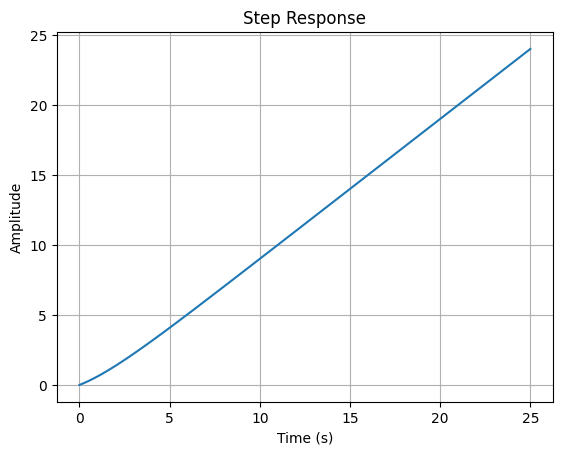

In [16]:
# Generate and plot the step response of the system
t, y = step_response(sys)
plt.plot(t, y)
plt.title('Step Response')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

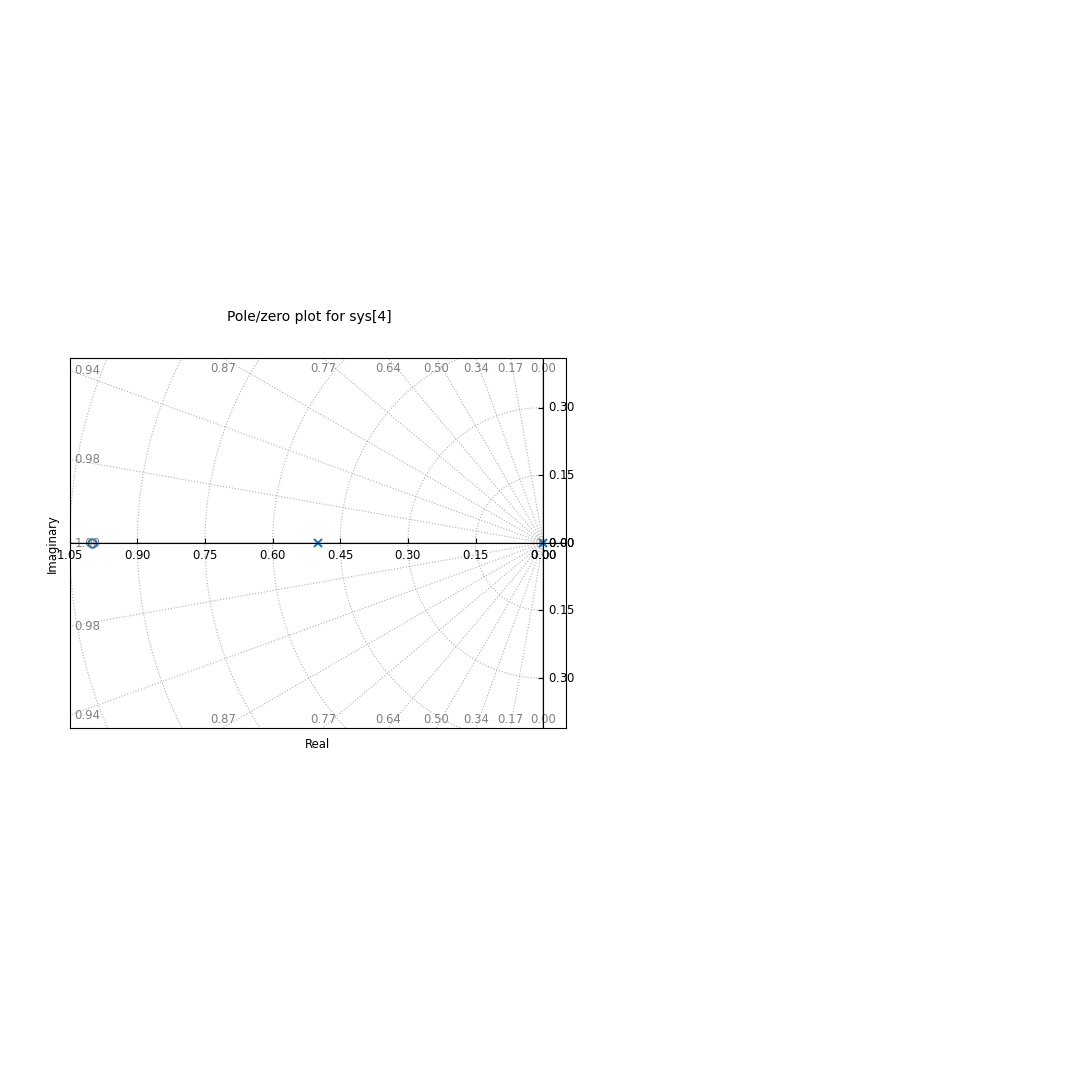

In [17]:
# Show pole-zero map for system analysis
pzmap(sys, grid=True)
plt.show()